In [3]:
import pandas as pd
import torch
import torch.nn as nn
from transformers import AutoTokenizer, EsmModel, EsmForMaskedLM
from tqdm.auto import tqdm
import itertools
import numpy as np
import os


DESIGN_SET_PATH = "final_design_set.csv"      
TRAIN_SET_PATH = "stratified_train.csv"             
MODEL_PATH = "stage2_esm_small_model_.pt"      
OUTPUT_FILE = "final_attention_guided_designs.csv"

MODEL_NAME = "facebook/esm2_t6_8M_UR50D"       
MAX_PEPTIDE_LEN = 30  
MAX_HLA_LEN = 34       
BATCH_SIZE = 128
NUM_CANDIDATES = 5
NUM_SAVES = 5
TOP_N_HLAS = 3  

class CrossAttentionMLMModel(nn.Module):
    def __init__(self, model_name="facebook/esm2_t6_8M_UR50D", num_heads=16): 
        super().__init__()
        self.encoder = EsmModel.from_pretrained(model_name)
        self.mlm_head = EsmForMaskedLM.from_pretrained(model_name).lm_head
        hidden_size = self.encoder.config.hidden_size 
        
        self.cross_attention = nn.MultiheadAttention(embed_dim=hidden_size, num_heads=num_heads, batch_first=True)
        self.layer_norm = nn.LayerNorm(hidden_size)
        self.dropout = nn.Dropout(0.1) 
        self.regression_head = nn.Sequential(nn.Linear(hidden_size, 256), nn.GELU(), nn.Dropout(0.1), nn.Linear(256, 1))

    def forward(self, input_ids, attention_mask, hla_ids, hla_mask, return_attention=False):
        peptide_embeds = self.encoder(input_ids=input_ids, attention_mask=attention_mask).last_hidden_state
        hla_embeds = self.encoder(input_ids=hla_ids, attention_mask=hla_mask).last_hidden_state
        mlm_logits = self.mlm_head(peptide_embeds)
        
        interaction_output, attn_weights = self.cross_attention(
            query=peptide_embeds, key=hla_embeds, value=hla_embeds, need_weights=True
        )
        
        updated_peptide_embeds = self.layer_norm(peptide_embeds + self.dropout(interaction_output))
        pic50_pred = self.regression_head(updated_peptide_embeds[:, 0, :])
        
        if return_attention:
            return mlm_logits, pic50_pred, attn_weights
        return mlm_logits, pic50_pred


@torch.no_grad()
def scan_top_hlas(model, parent_seq, hla_map, tokenizer, device, top_n=3):
    model.eval()
    hla_names = list(hla_map.keys())
    hla_seqs = list(hla_map.values())
    all_scores = []
    
    for i in range(0, len(hla_names), 32):
        batch_seqs = hla_seqs[i:i+32]
        p_inputs = tokenizer([parent_seq] * len(batch_seqs), max_length=MAX_PEPTIDE_LEN, padding='max_length', truncation=True, return_tensors='pt')
        h_inputs = tokenizer(batch_seqs, max_length=MAX_HLA_LEN, padding='max_length', truncation=True, return_tensors='pt')
        
        _, preds = model(p_inputs['input_ids'].to(device), p_inputs['attention_mask'].to(device), 
                         h_inputs['input_ids'].to(device), h_inputs['attention_mask'].to(device))
        all_scores.extend(preds.flatten().cpu().tolist())
    
    
    actual_n = min(top_n, len(all_scores))
    if actual_n == 0:
        return []
        
    top_indices = np.argsort(all_scores)[-actual_n:][::-1]
    
    return [{'hla_name': hla_names[idx], 'hla_seq': hla_seqs[idx], 'score': all_scores[idx]} for idx in top_indices]

@torch.no_grad()
def find_core_and_mask(model, parent_seq, hla_seq, tokenizer, device, mhc_class='I'):
    p_in = tokenizer(parent_seq, max_length=MAX_PEPTIDE_LEN, padding='max_length', truncation=True, return_tensors='pt')
    h_in = tokenizer(hla_seq, max_length=MAX_HLA_LEN, padding='max_length', truncation=True, return_tensors='pt')
    
    _, _, attn_map = model(p_in['input_ids'].to(device), p_in['attention_mask'].to(device), 
                           h_in['input_ids'].to(device), h_in['attention_mask'].to(device), return_attention=True)
    
    attention_tensor = attn_map[0]
    if attention_tensor.dim() == 3:
        peptide_importance = attention_tensor.mean(dim=0).max(dim=1).values.cpu().numpy()
    elif attention_tensor.dim() == 2:
        peptide_importance = attention_tensor.max(dim=1).values.cpu().numpy()
    else:
        peptide_importance = attention_tensor.mean(dim=-1).cpu().numpy()

    seq_len = len(parent_seq)
    valid_importance = peptide_importance[1 : 1 + seq_len]
    
    best_core_start = 0
    max_core_score = -1.0
    window_size = min(9, len(valid_importance))
        
    for i in range(len(valid_importance) - window_size + 1):
        score = np.sum(valid_importance[i : i + window_size])
        if score > max_core_score:
            max_core_score = score
            best_core_start = i
            
    core_importance = valid_importance[best_core_start : best_core_start + window_size]
    
    num_anchors_to_mask = 2 if mhc_class == 'I' else 3
    num_anchors_to_mask = min(num_anchors_to_mask, len(core_importance))
    
    top_anchor_indices_in_core = np.argsort(core_importance)[-num_anchors_to_mask:]
    top_anchor_indices_in_core.sort() 
    
    positions_to_mask = [best_core_start + idx for idx in top_anchor_indices_in_core]
    
    absolute_positions = [pos + 1 for pos in positions_to_mask]
    
    core_p_positions = [f"P{idx + 1}" for idx in top_anchor_indices_in_core]
            
    return positions_to_mask, best_core_start, absolute_positions, core_p_positions

@torch.no_grad()
def get_suggestions_and_filter(model, parent_seq, masked_indices, hla_seq, parent_score, tokenizer, device):
    seq_list = list(parent_seq)
    for idx in masked_indices:
        seq_list[idx] = tokenizer.mask_token
    masked_seq = " ".join(seq_list)
    
    p_in = tokenizer(masked_seq, max_length=MAX_PEPTIDE_LEN, padding='max_length', truncation=True, return_tensors='pt')
    h_in = tokenizer(hla_seq, max_length=MAX_HLA_LEN, padding='max_length', truncation=True, return_tensors='pt')
    mlm_logits, _ = model(p_in['input_ids'].to(device), p_in['attention_mask'].to(device), 
                          h_in['input_ids'].to(device), h_in['attention_mask'].to(device))
    
    token_options = []
    for idx in masked_indices:
        top_indices = torch.topk(mlm_logits[0, idx + 1], NUM_CANDIDATES).indices
        tokens = tokenizer.convert_ids_to_tokens(top_indices)
        clean = [t for t in tokens if len(t) == 1 and t.isalpha()]
        token_options.append(clean)
        
    if not token_options: return []
    
    cand_seqs = []
    for combo in itertools.product(*token_options):
        s_list = list(parent_seq)
        for i, idx in enumerate(masked_indices):
            s_list[idx] = combo[i]
        cand_seqs.append("".join(s_list))
        
    all_scores = []
    for i in range(0, len(cand_seqs), BATCH_SIZE):
        batch = cand_seqs[i:i+BATCH_SIZE]
        p_in = tokenizer(batch, max_length=MAX_PEPTIDE_LEN, padding='max_length', truncation=True, return_tensors='pt')
        h_in = tokenizer([hla_seq]*len(batch), max_length=MAX_HLA_LEN, padding='max_length', truncation=True, return_tensors='pt')
        
        _, preds = model(p_in['input_ids'].to(device), p_in['attention_mask'].to(device),
                         h_in['input_ids'].to(device), h_in['attention_mask'].to(device))
        all_scores.extend(preds.flatten().cpu().tolist())
        
    results = []
    for seq, score in zip(cand_seqs, all_scores):
        if score > parent_score:
            results.append({'sequence': seq, 'pic50': score, 'improvement': score - parent_score})
            
    results.sort(key=lambda x: x['pic50'], reverse=True)
    return results[:NUM_SAVES]

if __name__ == "__main__":
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print(f"Using device: {device}")
    
    tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
    model = CrossAttentionMLMModel(model_name=MODEL_NAME)
    
    if os.path.exists(MODEL_PATH):
        try:
            model.load_state_dict(torch.load(MODEL_PATH, map_location="cpu"), strict=False)
            print("Weights loaded successfully.")
        except Exception as e:
            print(f"Error loading weights: {e}"); exit()
    else:
        print(f"Model file '{MODEL_PATH}' not found."); exit()
        
    model.to(device)

    design_df = pd.read_csv(DESIGN_SET_PATH)
    train_df = pd.read_csv(TRAIN_SET_PATH)
    
    hla_col = 'HLA' if 'HLA' in train_df.columns else 'HLA_allele'
    hla_seq_map = dict(zip(train_df[hla_col], train_df['HLA_seq']))

    final_results = []

    print(f"Starting Multi-HLA Design (Top {TOP_N_HLAS} per peptide)...")
    
    for _, row in tqdm(design_df.iterrows(), total=len(design_df), desc="Processing Peptides"):
        parent_epitope = row['Parent_Epitope']
        peptide_len = len(parent_epitope)
        
        is_class_I_length = (8 <= peptide_len <= 11)
        is_class_II_length = (11 <= peptide_len <= 25)
        
        relevant_hla_map = {}
        for name, seq in hla_seq_map.items():
            is_class_II_allele = 'D' in name and ('R' in name or 'Q' in name or 'P' in name)
            
            if is_class_I_length and not is_class_II_allele:
                relevant_hla_map[name] = seq
            elif is_class_II_length and is_class_II_allele:
                relevant_hla_map[name] = seq
                
        if not relevant_hla_map:
            print(f"\nSkipping {parent_epitope}: Length {peptide_len} does not match any available alleles for scanning.")
            continue
        
        top_hla_targets = scan_top_hlas(model, parent_epitope, relevant_hla_map, tokenizer, device, top_n=TOP_N_HLAS)
        
        for target in top_hla_targets:
            hla_name = target['hla_name']
            hla_seq = target['hla_seq']
            initial_score = target['score']
            
            mhc_class = 'II' if 'D' in hla_name and ('R' in hla_name or 'Q' in hla_name) else 'I'

            mask_indices, core_start, abs_pos, core_pos = find_core_and_mask(model, parent_epitope, hla_seq, tokenizer, device, mhc_class)
            
            if not mask_indices:
                continue

            top_designs = get_suggestions_and_filter(model, parent_epitope, mask_indices, hla_seq, initial_score, tokenizer, device)

            for design in top_designs:
                final_results.append({
                    'Parent': parent_epitope,
                    'Target_HLA': hla_name,               
                    'Initial_pIC50': round(initial_score, 2),
                    'Predicted_Core_Start': core_start,
                    'Absolute_Mutation_Pos': str(abs_pos),   
                    'Core_Relative_Pos': str(core_pos),      
                    'Designed_Sequence': design['sequence'],
                    'Designed_pIC50': round(design['pic50'], 2),
                    'Improvement': round(design['improvement'], 2)
                })

    if final_results:
        out_df = pd.DataFrame(final_results)
        out_df.to_csv(OUTPUT_FILE, index=False)
        print(f"\nDone! Generated {len(out_df)} designs.")
        print(f"Results saved to: {OUTPUT_FILE}")
    else:
        print("\nNo designs found that improved binding affinity.")

Using device: cpu


Some weights of EsmModel were not initialized from the model checkpoint at facebook/esm2_t6_8M_UR50D and are newly initialized: ['pooler.dense.bias', 'pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Weights loaded successfully.
Starting Multi-HLA Design (Top 3 per peptide)...


Processing Peptides:   0%|          | 0/415 [00:00<?, ?it/s]


Skipping DDEHVEEPTVADDEHVEEPTVADDEHVEEPTVA: Length 33 does not match any available alleles for scanning.

Skipping EENVEHDAEENVEHDAEENVEHDAEENVEHDA: Length 32 does not match any available alleles for scanning.

Skipping EKVDNLGRSGGDIIKKMQTLWDEIMDINKRK: Length 31 does not match any available alleles for scanning.

Skipping EQQSDLEQERLAKEKLQEQQSDLEQERRAKEKLQ: Length 34 does not match any available alleles for scanning.

Skipping GDRADGQPAGDRADGQPAGDRADGQPAGDRADGQPA: Length 36 does not match any available alleles for scanning.

Skipping HVGQSASRGRGLGENPDDEEVRRRVNAANKKPEDLTLNDL: Length 40 does not match any available alleles for scanning.

Done! Generated 5316 designs.
Results saved to: final_attention_guided_designs.csv


In [1]:
import pandas as pd

file_path = "final_attention_guided_designs.csv"

df = pd.read_csv(file_path)

unique_hlas = sorted(df['Target_HLA'].unique().tolist())

print(f"Total unique HLAs targeted: {len(unique_hlas)}\n")
print("List of Unique HLAs:")
for hla in unique_hlas:
    print(f"- {hla}")

Total unique HLAs targeted: 90

List of Unique HLAs:
- DRB1_0101
- DRB1_0102
- DRB1_0103
- DRB1_0301
- DRB1_0302
- DRB1_0401
- DRB1_0402
- DRB1_0403
- DRB1_0404
- DRB1_0405
- DRB1_0406
- DRB1_0411
- DRB1_0701
- DRB1_0801
- DRB1_0802
- DRB1_1001
- DRB1_1101
- DRB1_1201
- DRB1_1301
- DRB1_1302
- DRB1_1501
- DRB1_1602
- DRB3_0101
- DRB3_0202
- DRB3_0301
- DRB4_0101
- DRB4_0103
- DRB5_0101
- HLA-A*02:01
- HLA-A*02:02
- HLA-A*02:03
- HLA-A*02:06
- HLA-A*02:11
- HLA-A*02:16
- HLA-A*02:50
- HLA-A*03:01
- HLA-A*11:01
- HLA-A*29:02
- HLA-A*30:01
- HLA-A*31:01
- HLA-A*32:07
- HLA-A*33:01
- HLA-A*68:01
- HLA-A*68:23
- HLA-B*07:02
- HLA-B*08:01
- HLA-B*15:01
- HLA-B*15:02
- HLA-B*15:03
- HLA-B*15:17
- HLA-B*27:20
- HLA-B*35:01
- HLA-B*35:03
- HLA-B*40:02
- HLA-B*45:01
- HLA-B*51:01
- HLA-B*52:01
- HLA-B*53:01
- HLA-B*54:01
- HLA-B*57:01
- HLA-B*57:03
- HLA-B*58:01
- HLA-B*83:01
- HLA-DPA10103-DPB10201
- HLA-DPA10103-DPB10301
- HLA-DPA10103-DPB10401
- HLA-DPA10103-DPB10402
- HLA-DPA10103-DPB10601
-

In [2]:
# A pIC50 of 6.3 corresponds to 500nM (Moderate)
# A pIC50 of 7.3 corresponds to 50nM (Strong)

weak_parents = df[df['Initial_pIC50'] < 6.3]
strong_designs = weak_parents[weak_parents['Designed_pIC50'] > 7.3]

shift_percentage = (len(strong_designs) / len(weak_parents)) * 100
print(f"Percentage of weak binders shifted to strong: {shift_percentage:.1f}%")

Percentage of weak binders shifted to strong: 6.1%


In [4]:
from Bio.SeqUtils.ProtParam import ProteinAnalysis

def get_gravy(seq):
    return ProteinAnalysis(seq).gravy()

df['Parent_Gravy'] = df['Parent'].apply(get_gravy)
df['Designed_Gravy'] = df['Designed_Sequence'].apply(get_gravy)

mean_gravy_shift = (df['Designed_Gravy'] - df['Parent_Gravy']).mean()
print(f"Mean Gravy Index Shift: {mean_gravy_shift:.2f}")

Mean Gravy Index Shift: -0.01


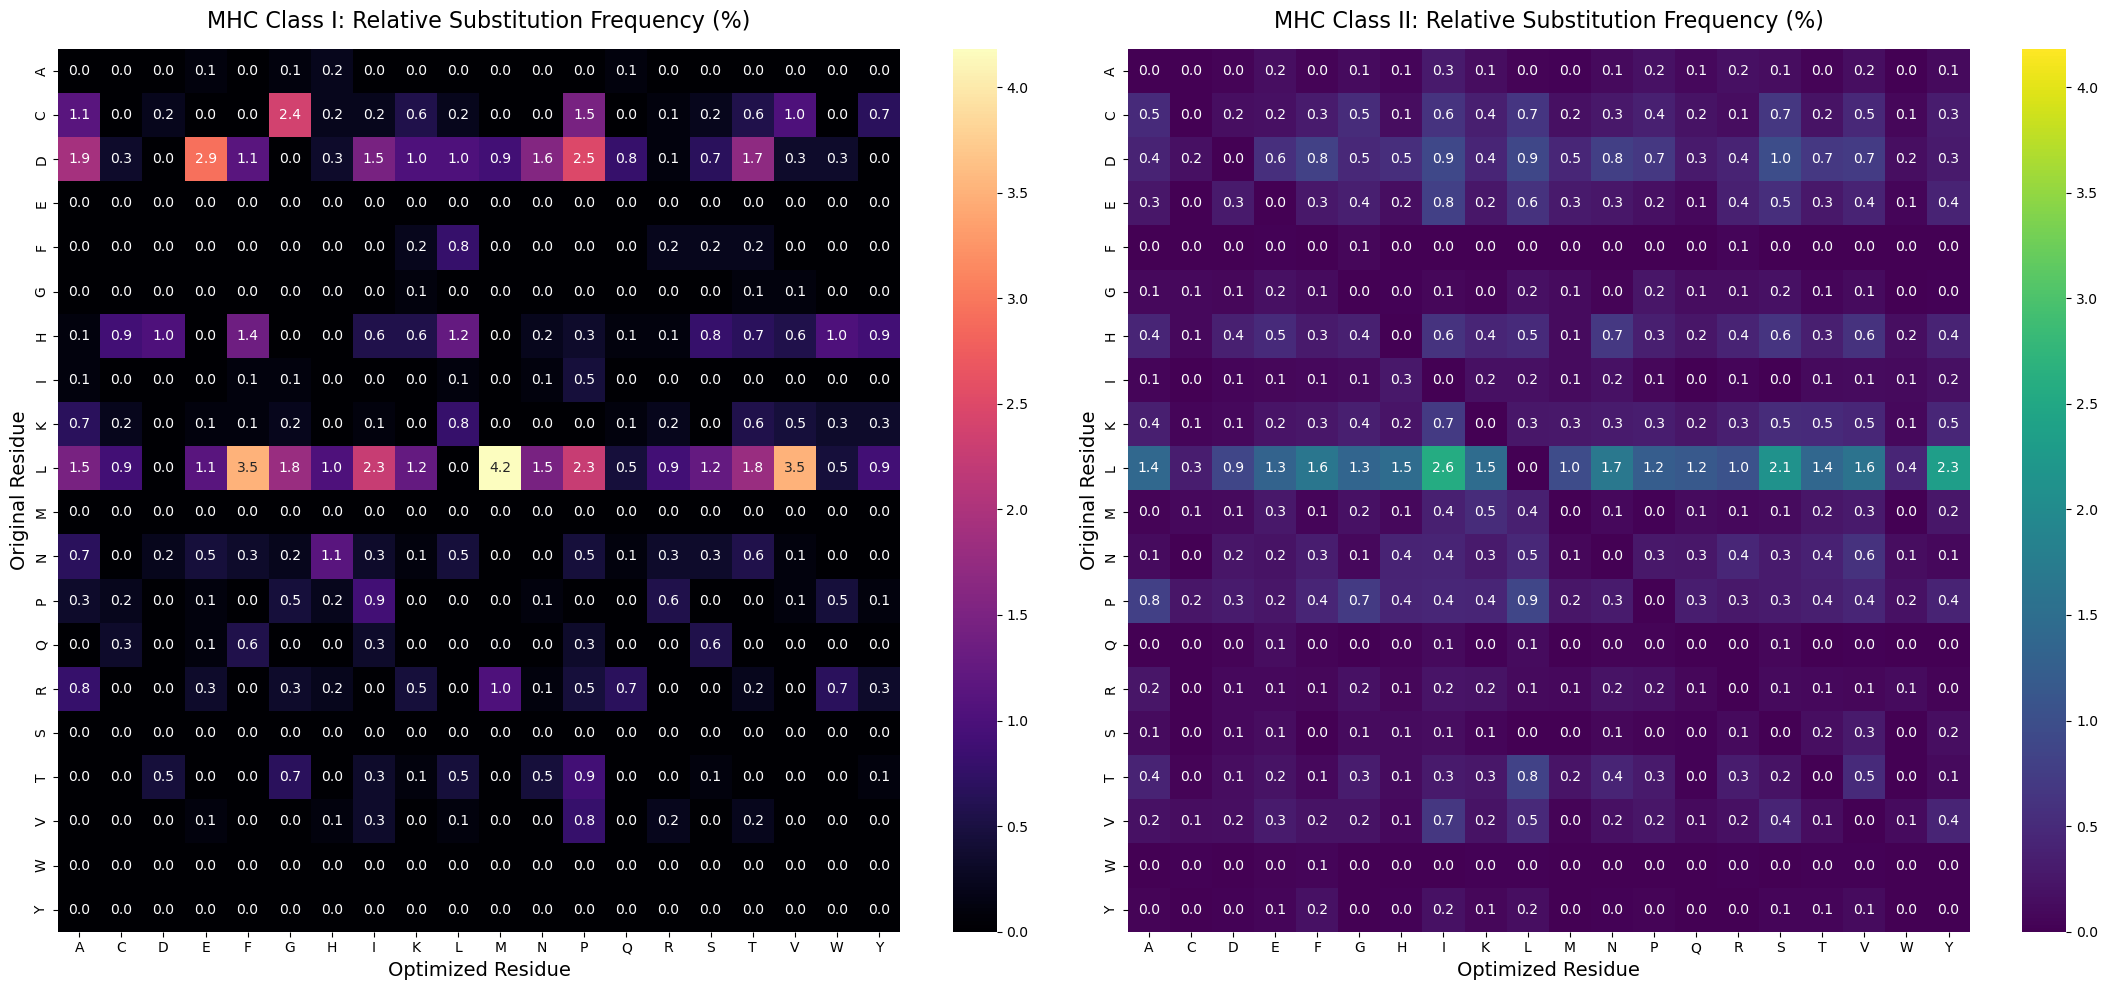

In [11]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

df = pd.read_csv("final_attention_guided_designs.csv")

def get_normalized_matrix(dataframe, hla_filter_func):
    amino_acids = list("ACDEFGHIKLMNPQRSTVWY")
    matrix = pd.DataFrame(0.0, index=amino_acids, columns=amino_acids)
    total_mutations = 0
    
    for _, row in dataframe.iterrows():
        if hla_filter_func(row['Target_HLA']):
            parent, designed = row['Parent'], row['Designed_Sequence']
            for p_aa, d_aa in zip(parent, designed):
                if p_aa != d_aa:
                    matrix.loc[p_aa, d_aa] += 1
                    total_mutations += 1

    if total_mutations > 0:
        matrix = (matrix / total_mutations) * 100
    return matrix

is_class_ii = lambda h: any(x in str(h) for x in ['DR', 'DP', 'DQ'])
is_class_i  = lambda h: not is_class_ii(h)

matrix_i_norm  = get_normalized_matrix(df, is_class_i)
matrix_ii_norm = get_normalized_matrix(df, is_class_ii)

fig, axes = plt.subplots(1, 2, figsize=(22, 10))
v_max = max(matrix_i_norm.max().max(), matrix_ii_norm.max().max())

sns.heatmap(matrix_i_norm, annot=True, fmt=".1f", cmap="magma", ax=axes[0], vmin=0, vmax=v_max)
axes[0].set_title("MHC Class I: Relative Substitution Frequency (%)", fontsize=16, pad=15)
axes[0].set_ylabel("Original Residue", fontsize=14)
axes[0].set_xlabel("Optimized Residue", fontsize=14)

sns.heatmap(matrix_ii_norm, annot=True, fmt=".1f", cmap="viridis", ax=axes[1], vmin=0, vmax=v_max)
axes[1].set_title("MHC Class II: Relative Substitution Frequency (%)", fontsize=16, pad=15)
axes[1].set_ylabel("Original Residue", fontsize=14)
axes[1].set_xlabel("Optimized Residue", fontsize=14)

plt.tight_layout()
plt.savefig("normalized_mhc_heatmaps_labeled.png", dpi=300)
plt.show()

In [8]:
import pandas as pd

df = pd.read_csv("final_attention_guided_designs.csv")

def get_mhc_class(hla):
    if any(x in str(hla) for x in ['DR', 'DP', 'DQ']):
        return 'II'
    return 'I'

df['MHC_Class'] = df['Target_HLA'].apply(get_mhc_class)

counts = df['MHC_Class'].value_counts()
unique_parents = df.groupby('MHC_Class')['Parent'].nunique()
avg_improvements = df.groupby('MHC_Class')['Improvement'].mean()

print("MHC Class Counts in Designs:")
print(counts)
print("\nUnique Parent Epitopes per Class:")
print(unique_parents)
print("\nAverage pIC50 Improvement per Class:")
print(avg_improvements)

MHC Class Counts in Designs:
MHC_Class
II    4799
I      517
Name: count, dtype: int64

Unique Parent Epitopes per Class:
MHC_Class
I      44
II    358
Name: Parent, dtype: int64

Average pIC50 Improvement per Class:
MHC_Class
I     0.524391
II    0.558395
Name: Improvement, dtype: float64
